# Impedance Alignment Demo Notebook

This notebook reproduces one representative stiff-vs-impedance comparison and key plots from the project.


## What this notebook does
1. Regenerates canonical comparison logs (stiff and impedance).
2. Loads `results/run_stiff.csv` and `results/run_impedance.csv`.
3. Plots force and center-error trajectories.
4. Plots top-down peg path relative to hole clearance.


In [1]:
from __future__ import annotations

import csv
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path) -> Path:
    if (start / "simulation").exists():
        return start
    if (start.parent / "simulation").exists():
        return start.parent
    raise RuntimeError("Could not locate repo root with simulation/ directory.")


ROOT = find_repo_root(Path.cwd())
RESULTS = ROOT / "results"
print(f"Repo root: {ROOT}")


Repo root: c:\myData\Training\Artificial Intelegence\Udemy_AI_Coder\Robotics\impedance-contrller


In [2]:
# Regenerate canonical logs and validate the core stiff-vs-impedance story.
subprocess.run([sys.executable, "-m", "experiments.prepare_web_data"], cwd=ROOT, check=True)


CompletedProcess(args=['c:\\myData\\Training\\Artificial Intelegence\\Udemy_AI_Coder\\Robotics\\impedance-contrller\\.venv\\Scripts\\python.exe', '-m', 'experiments.prepare_web_data'], returncode=0)

In [3]:
def load_csv(path: Path) -> dict[str, np.ndarray]:
    with path.open("r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        rows = list(reader)
    if not rows:
        raise RuntimeError(f"No rows in {path}")

    numeric_keys = [k for k in rows[0].keys() if k not in ("mode",)]
    out: dict[str, np.ndarray] = {}
    for key in numeric_keys:
        out[key] = np.array([float(r[key]) for r in rows], dtype=np.float64)
    return out


stiff = load_csv(RESULTS / "run_stiff.csv")
imp = load_csv(RESULTS / "run_impedance.csv")
stiff_meta = json.loads((RESULTS / "run_stiff_meta.json").read_text(encoding="utf-8"))
imp_meta = json.loads((RESULTS / "run_impedance_meta.json").read_text(encoding="utf-8"))


In [4]:
def summary_row(meta: dict[str, object]) -> dict[str, object]:
    s = meta["summary"]
    return {
        "mode": s["mode"],
        "success": s["success"],
        "insertion_time_s": s["insertion_time_s"],
        "peak_contact_force_n": round(float(s["peak_contact_force_n"]), 3),
        "max_lateral_error_m": round(float(s["max_lateral_error_m"]), 6),
    }


rows = [summary_row(stiff_meta), summary_row(imp_meta)]
for r in rows:
    print(r)


{'mode': 'stiff', 'success': False, 'insertion_time_s': None, 'peak_contact_force_n': 56.96, 'max_lateral_error_m': 0.002151}
{'mode': 'impedance', 'success': True, 'insertion_time_s': 0.7820000000000006, 'peak_contact_force_n': 36.525, 'max_lateral_error_m': 0.002558}


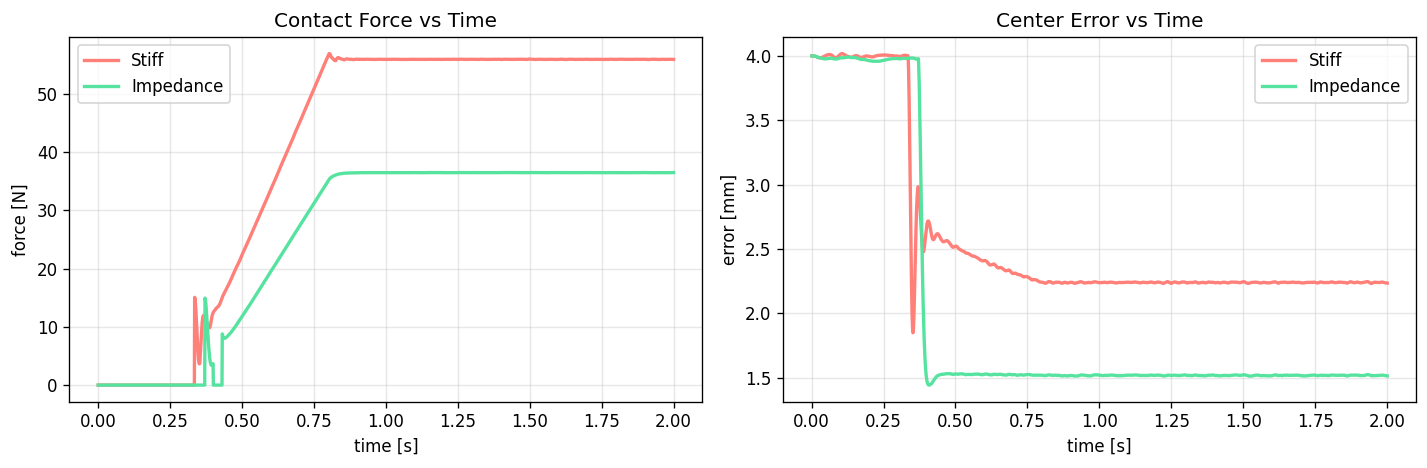

In [5]:
# Key plot 1: force and center-error trajectories
fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=120)

ax[0].plot(stiff["t_s"], stiff["contact_force_n"], label="Stiff", color="#ff7f79", lw=2)
ax[0].plot(imp["t_s"], imp["contact_force_n"], label="Impedance", color="#56e39f", lw=2)
ax[0].set_title("Contact Force vs Time")
ax[0].set_xlabel("time [s]")
ax[0].set_ylabel("force [N]")
ax[0].grid(alpha=0.3)
ax[0].legend()

stiff_center_err = np.sqrt(stiff["x_m"] ** 2 + stiff["y_m"] ** 2) * 1000.0
imp_center_err = np.sqrt(imp["x_m"] ** 2 + imp["y_m"] ** 2) * 1000.0
ax[1].plot(stiff["t_s"], stiff_center_err, label="Stiff", color="#ff7f79", lw=2)
ax[1].plot(imp["t_s"], imp_center_err, label="Impedance", color="#56e39f", lw=2)
ax[1].set_title("Center Error vs Time")
ax[1].set_xlabel("time [s]")
ax[1].set_ylabel("error [mm]")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()


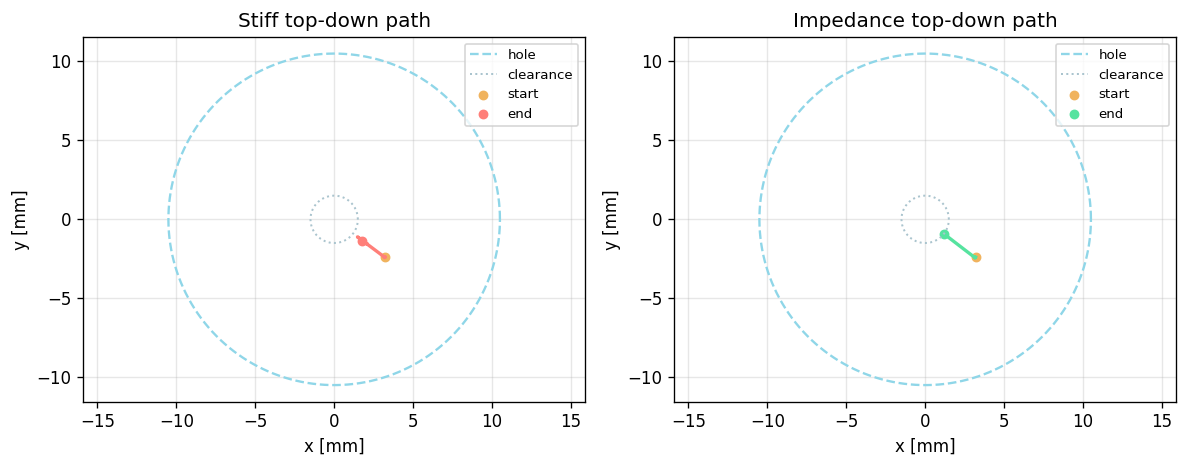

In [6]:
# Key plot 2: top-down trajectory with hole and clearance circles
hole_radius = 0.0105
peg_radius = 0.0090
clearance = hole_radius - peg_radius

theta = np.linspace(0, 2 * np.pi, 360)
fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=120)

for idx, (trace, title, color) in enumerate(
    [
        (stiff, "Stiff", "#ff7f79"),
        (imp, "Impedance", "#56e39f"),
    ]
):
    a = ax[idx]
    a.plot(trace["x_m"] * 1000.0, trace["y_m"] * 1000.0, color=color, lw=2)
    a.plot(
        1000 * hole_radius * np.cos(theta),
        1000 * hole_radius * np.sin(theta),
        "--",
        color="#8fd6e8",
        lw=1.4,
        label="hole",
    )
    a.plot(
        1000 * clearance * np.cos(theta),
        1000 * clearance * np.sin(theta),
        ":",
        color="#aac4ce",
        lw=1.2,
        label="clearance",
    )
    a.scatter(
        [trace["x_m"][0] * 1000.0],
        [trace["y_m"][0] * 1000.0],
        color="#f0b35e",
        s=24,
        label="start",
    )
    a.scatter(
        [trace["x_m"][-1] * 1000.0],
        [trace["y_m"][-1] * 1000.0],
        color=color,
        s=24,
        label="end",
    )
    a.set_title(f"{title} top-down path")
    a.set_xlabel("x [mm]")
    a.set_ylabel("y [mm]")
    a.grid(alpha=0.3)
    a.axis("equal")
    a.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()


## Interpretation
- The stiff trace shows higher contact-force peaks and non-insertion.
- The impedance trace inserts successfully while reducing peak contact force.
- The top-down trajectory shows compliant self-centering behavior in impedance mode.
